# **Task A**

- Name : Vaishnavi Agarwal
- Roll No.: 230150028

# Importing Libraries


In [21]:
from scipy.integrate import trapezoid
import numpy as np
import matplotlib.pyplot as plt

Completing the given fourier series function

In [22]:
def compute_Fourier_Series(x, t, K, T):

    N = len(t)
    dt = t[1] - t[0]
    c = []
    for k in range(-K, K+1):
        integrand = x * np.exp(-1j * 2 * np.pi * k * t / T)
        ck = (1.0/T) * trapezoid(integrand, t)
        c.append(ck)
    return np.array(c)

Signal reconstruction

In [23]:
def reconstruct_signal(c, t, K, T):
    ks = np.arange(-K, K+1)
    x_hat = np.zeros_like(t, dtype=complex)
    for idx, k in enumerate(ks):
        x_hat += c[idx] * np.exp(1j * 2 * np.pi * k * t / T)
    return x_hat.real

# **(a) Exploring Polynomial Structures with Fourier Series**

- Chebyshev Polynomial T5(t)

In [24]:
def chebyshev_t(x, n):
  if n == 0:
      return 1
  elif n == 1:
      return x
  else:
      return 2 * x * chebyshev_t(x, n-1) - chebyshev_t(x, n-2)

t = np.linspace(-1, 1, 2000)
T = 2  
x = chebyshev_t(t,5)
Ks = [5, 20, 30, 50, 75, 90]
errors = []

# (i) Error as K increases

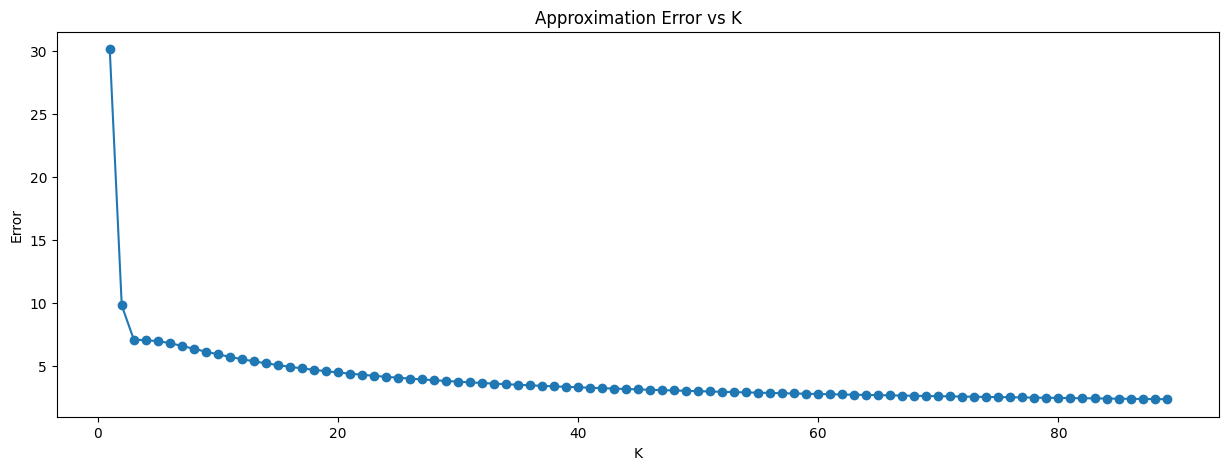

In [25]:

plt.figure(figsize=(15, 5))


K_range = range(1, 90)
for K in K_range:
    c = compute_Fourier_Series(x, t, K, T)
    x_hat = reconstruct_signal(c, t, K, T)
    err = np.linalg.norm(x - x_hat)
    errors.append(err)

plt.plot(K_range, errors, marker='o')
plt.title("Approximation Error vs K")
plt.xlabel("K")
plt.ylabel("Error")
plt.show()

**Observation :**</br>
Fourier approximation improves as more harmonics are included.

# (ii) Overlay for small vs large K

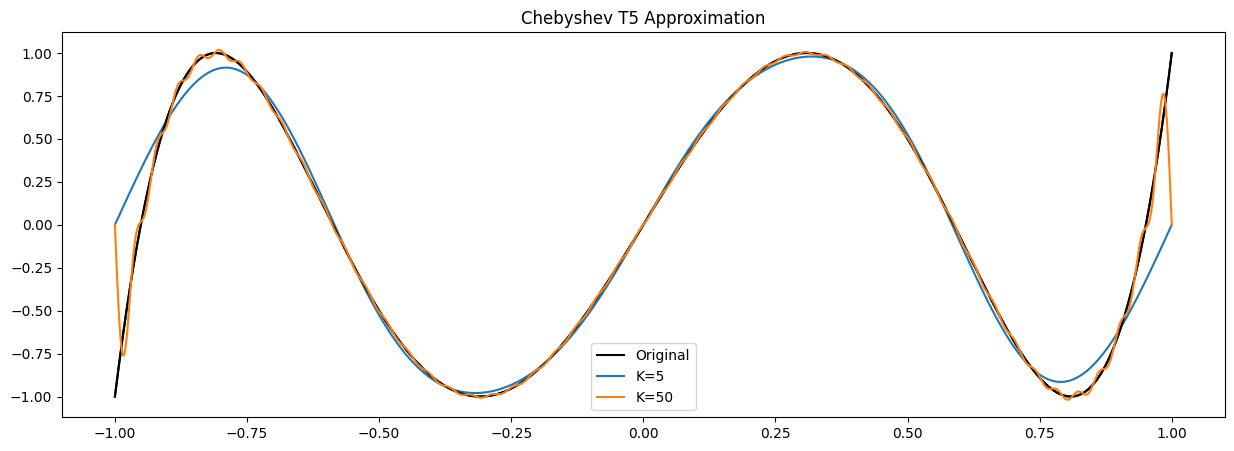

In [26]:
plt.figure(figsize=(15, 5))
for i, K in enumerate([5,50]):
    c = compute_Fourier_Series(x, t, K, T)
    x_hat = reconstruct_signal(c, t, K, T)
   
    plt.plot(t, x, 'k', label="Original" if i == 0 else "")
    plt.plot(t, x_hat, label=f"K={K}")
plt.title("Chebyshev T5 Approximation")
plt.legend()
plt.show()

# (iii) Fourier coefficients spectrum

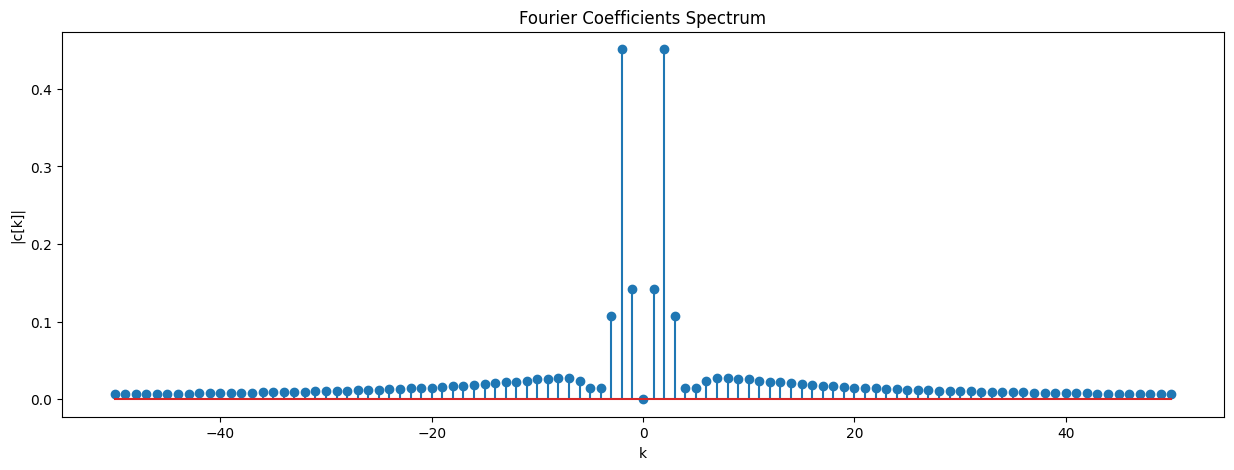

In [27]:
K = 50
c = compute_Fourier_Series(x, t, K, T)
ks = np.arange(-K, K+1)
plt.figure(figsize=(15, 5))
plt.stem(ks, np.abs(c))
plt.title("Fourier Coefficients Spectrum")
plt.xlabel("k")
plt.ylabel("|c[k]|")

plt.show()

**Observation:**</br>
The magnitude spectrum ∣𝑐[𝑘]∣ is strongest around low values of 𝑘 </br>
Higher-order harmonics have much smaller coefficients.</br>
This indicates that most of the signal’s energy is concentrated in lower frequencies.

# **(b) The Mystery of Gibbs Phenomenon**

In [28]:
def square_pulse(t, p, T):
    t_mod = ((t + T/2) % T) - T/2
    x = np.where(np.abs(t_mod) < p/2, 1.0, 0.0)
    return x

In [29]:
T = 1
t = np.linspace(-0.5, 0.5, 2000)
p = 1.0
x = square_pulse(t,p,T)
print(x[:10])



[0. 1. 1. 1. 1. 1. 1. 1. 1. 1.]



=== Fourier Approximation with K = 50 ===
Fourier coefficients c[k]:
[-5.00250125e-04-6.93889390e-18j  5.00250125e-04-3.90312782e-17j
 -5.00250125e-04+3.46944695e-17j  5.00250125e-04-3.03576608e-17j
 -5.00250125e-04-1.64798730e-17j  5.00250125e-04+1.99493200e-17j
 -5.00250125e-04-3.29597460e-17j  5.00250125e-04+8.67361738e-18j
 -5.00250125e-04-5.20417043e-17j  5.00250125e-04-1.04083409e-17j
 -5.00250125e-04+2.34187669e-17j  5.00250125e-04+2.16840434e-17j
 -5.00250125e-04-1.38777878e-16j  5.00250125e-04-3.12250226e-17j
 -5.00250125e-04-1.99493200e-17j  5.00250125e-04-2.94902991e-17j
 -5.00250125e-04+8.67361738e-18j  5.00250125e-04+1.21430643e-17j
 -5.00250125e-04-2.50450702e-17j  5.00250125e-04+6.93889390e-18j
 -5.00250125e-04+5.20417043e-18j  5.00250125e-04-2.25514052e-17j
 -5.00250125e-04-2.25514052e-17j  5.00250125e-04+1.38777878e-17j
 -5.00250125e-04-5.20417043e-18j  5.00250125e-04-1.73472348e-18j
 -5.00250125e-04+8.67361738e-18j  5.00250125e-04+4.16333634e-17j
 -5.00250125e-04-1.7

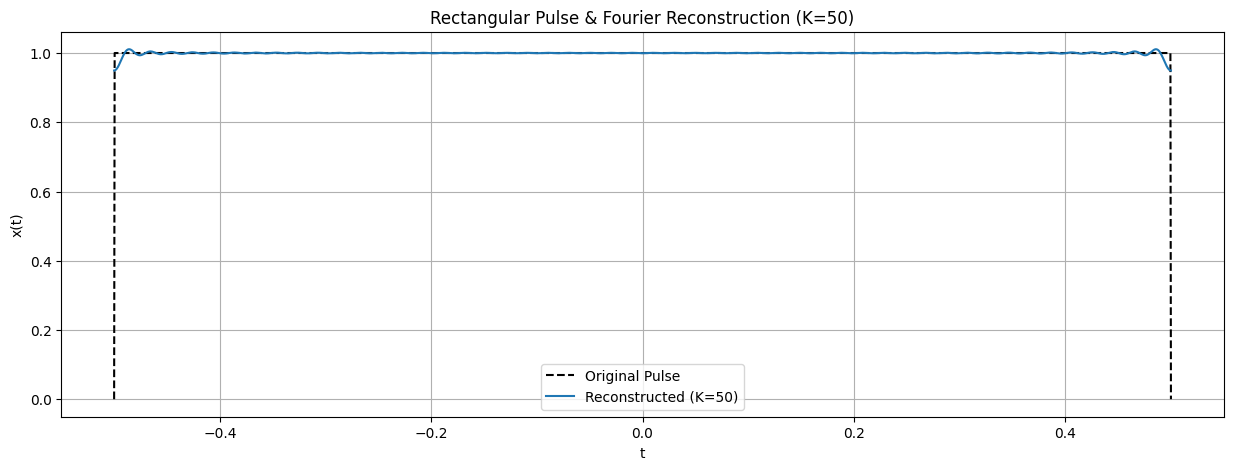

In [30]:
K= 50
print(f"\n=== Fourier Approximation with K = {K} ===")

c = compute_Fourier_Series(x, t, K, T)
print("Fourier coefficients c[k]:")
print(c)
x_hat = reconstruct_signal(c, t, K, T)
print("First 10 reconstructed values:")
print(x_hat[:10])
    

plt.figure(figsize=(15,5))
plt.plot(t, x, 'k--', label="Original Pulse")
plt.plot(t, x_hat, label=f"Reconstructed (K={K})")
plt.title(f"Rectangular Pulse & Fourier Reconstruction (K={K})")
plt.xlabel("t")
plt.ylabel("x(t)")
plt.legend()
plt.grid(True)
plt.show()


=== Fourier Approximation with K = 100 ===
Fourier coefficients c[k]:
[-5.00250125e-04+9.37834879e-17j  5.00250125e-04-9.41087486e-17j
 -5.00250125e-04+2.34187669e-17j  5.00250125e-04+3.59955121e-17j
 -5.00250125e-04+1.30537942e-16j  5.00250125e-04+5.81132364e-17j
 -5.00250125e-04-2.99239800e-17j  5.00250125e-04+1.34441069e-16j
 -5.00250125e-04-3.90312782e-18j  5.00250125e-04+6.08020578e-16j
 -5.00250125e-04+7.41594286e-17j  5.00250125e-04-1.47451495e-17j
 -5.00250125e-04-4.48859699e-17j  5.00250125e-04-7.63278329e-17j
 -5.00250125e-04+9.10729825e-18j  5.00250125e-04+5.20417043e-18j
 -5.00250125e-04-1.17093835e-17j  5.00250125e-04-2.16840434e-18j
 -5.00250125e-04+3.59955121e-17j  5.00250125e-04+1.73472348e-18j
 -5.00250125e-04-7.91467586e-18j  5.00250125e-04+1.34441069e-17j
 -5.00250125e-04-1.30104261e-18j  5.00250125e-04-6.59194921e-17j
 -5.00250125e-04-1.38777878e-17j  5.00250125e-04-1.56125113e-17j
 -5.00250125e-04-4.16333634e-17j  5.00250125e-04+3.33934269e-17j
 -5.00250125e-04-3.

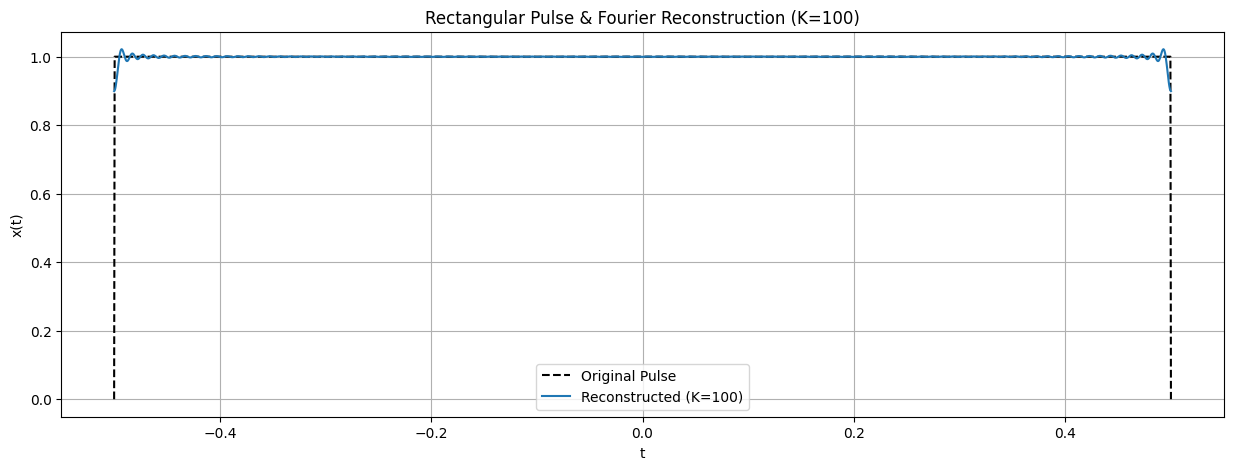

In [31]:
K= 100
print(f"\n=== Fourier Approximation with K = {K} ===")

c = compute_Fourier_Series(x, t, K, T)
print("Fourier coefficients c[k]:")
print(c)
x_hat = reconstruct_signal(c, t, K, T)
print("First 10 reconstructed values:")
print(x_hat[:10])
    

plt.figure(figsize=(15,5))
plt.plot(t, x, 'k--', label="Original Pulse")
plt.plot(t, x_hat, label=f"Reconstructed (K={K})")
plt.title(f"Rectangular Pulse & Fourier Reconstruction (K={K})")
plt.xlabel("t")
plt.ylabel("x(t)")
plt.legend()
plt.grid(True)
plt.show()


=== Fourier Approximation with K = 200 ===
Fourier coefficients c[k]:
[-5.00250125e-04-2.09251019e-16j  5.00250125e-04-8.67903839e-17j
 -5.00250125e-04+2.55871713e-17j  5.00250125e-04+4.83879430e-16j
 -5.00250125e-04-1.24249569e-16j  5.00250125e-04+8.23668390e-16j
 -5.00250125e-04+2.53703308e-16j  5.00250125e-04+1.97107955e-16j
 -5.00250125e-04+5.39932682e-17j  5.00250125e-04+1.52655666e-16j
 -5.00250125e-04-7.75855075e-16j  5.00250125e-04-3.84891771e-16j
 -5.00250125e-04+2.94902991e-17j  5.00250125e-04-2.85145171e-17j
 -5.00250125e-04+9.10729825e-18j  5.00250125e-04+1.80844922e-16j
 -5.00250125e-04+2.23345648e-17j  5.00250125e-04+2.48065457e-16j
 -5.00250125e-04-4.62737487e-16j  5.00250125e-04-5.17164436e-17j
 -5.00250125e-04-7.32920669e-17j  5.00250125e-04+9.41087486e-17j
 -5.00250125e-04-1.21430643e-17j  5.00250125e-04+4.04407410e-17j
 -5.00250125e-04+4.56232274e-16j  5.00250125e-04-4.33680869e-19j
 -5.00250125e-04-4.81385765e-17j  5.00250125e-04-1.99493200e-17j
 -5.00250125e-04-3.

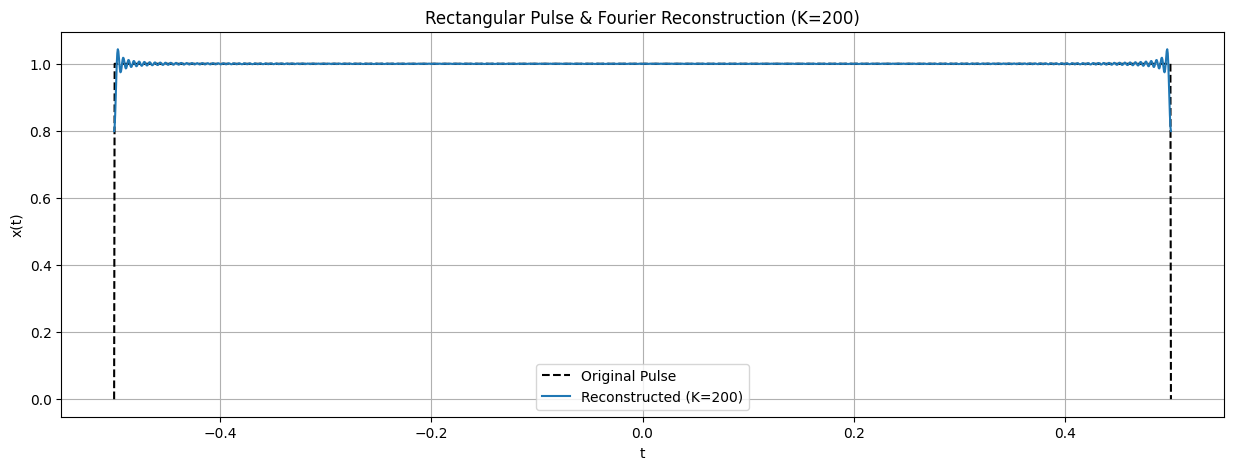

In [32]:
K= 200
print(f"\n=== Fourier Approximation with K = {K} ===")

c = compute_Fourier_Series(x, t, K, T)
print("Fourier coefficients c[k]:")
print(c)
x_hat = reconstruct_signal(c, t, K, T)
print("First 10 reconstructed values:")
print(x_hat[:10])
    

plt.figure(figsize=(15,5))
plt.plot(t, x, 'k--', label="Original Pulse")
plt.plot(t, x_hat, label=f"Reconstructed (K={K})")
plt.title(f"Rectangular Pulse & Fourier Reconstruction (K={K})")
plt.xlabel("t")
plt.ylabel("x(t)")
plt.legend()
plt.grid(True)
plt.show()

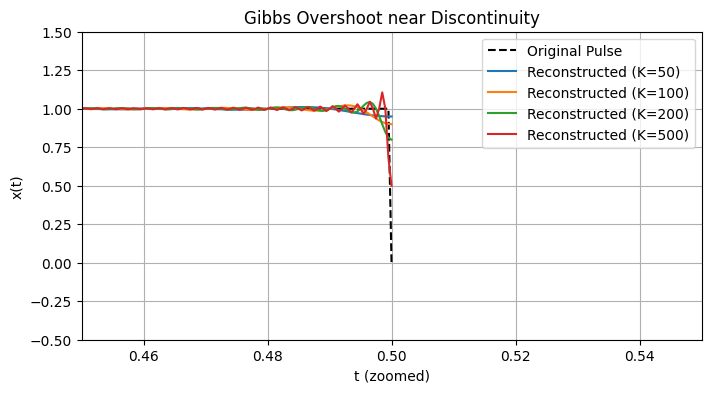

In [33]:
plt.figure(figsize=(8,4))
plt.plot(t, x, 'k--', label="Original Pulse")

for K in [50, 100, 200, 500]:
    c = compute_Fourier_Series(x, t, K, T)
    x_hat = reconstruct_signal(c, t, K, T)
    plt.plot(t, x_hat, label=f"Reconstructed (K={K})")

plt.xlim(0.45, 0.55)  # zoom around edge at 0.5 to show discontuinity clearly
plt.ylim(-0.5, 1.5) 
plt.title("Gibbs Overshoot near Discontinuity")
plt.xlabel("t (zoomed)")
plt.ylabel("x(t)")
plt.legend()
plt.grid(True)
plt.show()

- **Why does the Fourier approximation overshoot near discontinuities?**

This is because Fourier series uses sinusoidal signals to approximate discontinuities at the edges which overshoots. This phenomenon is what is called the Gibbs Phenomenon.


- **Why does this effect not vanish as K → ∞?**

A Fourier series is a sum of a finite (or potentially infinite) number of continuous sinusoidal functions. When approximating a function with a jump discontinuity, these continuous waves cannot perfectly capture the abrupt change. While the width of the overshoot shrinks and moves closer to the discontinuity with more terms, its height converges to a finite, non-zero value (approximately 9% of the jump in the function's value). 


# **(c) Clipped Sinusoid**

In [34]:
f0 = 5
T = 1
t = np.linspace(0, 1, 2000)
sine = np.sin(2*np.pi*f0*t)
x = np.where(sine > 0.7, 1, np.where(sine < -0.7, -1, sine))


# (i) Reconstruction

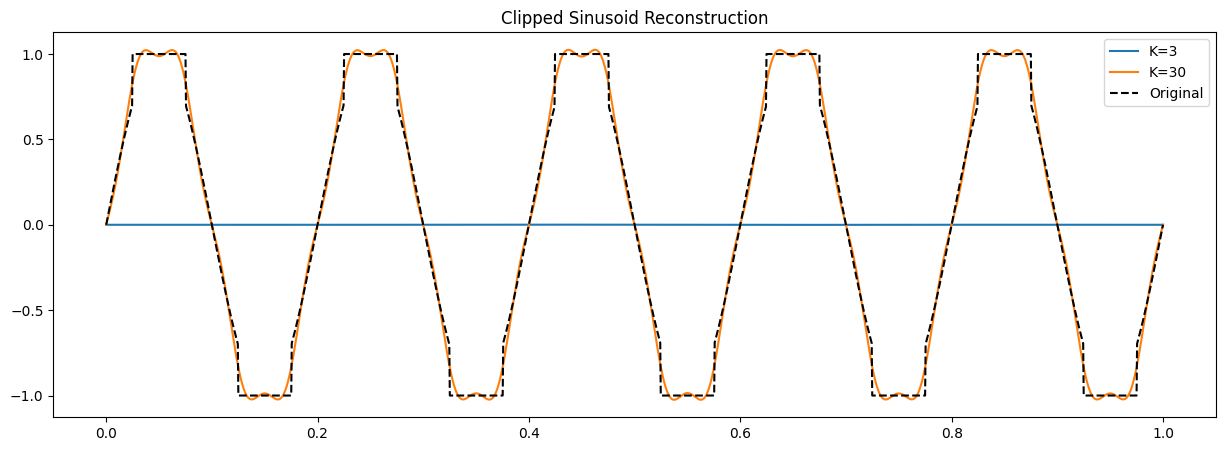

In [35]:

plt.figure(figsize=(15, 5))
for i, K in enumerate([3, 30]):
    c = compute_Fourier_Series(x, t, K, T)
    x_hat = reconstruct_signal(c, t, K, T)
 
    plt.plot(t, x_hat, label=f"K={K}")
plt.plot(t, x, 'k--', label="Original")
plt.title("Clipped Sinusoid Reconstruction")
plt.legend()
plt.show()

Increasing K improves accuracy but never fully eliminates ringing (similar to Gibbs).

# (ii) Spectrum

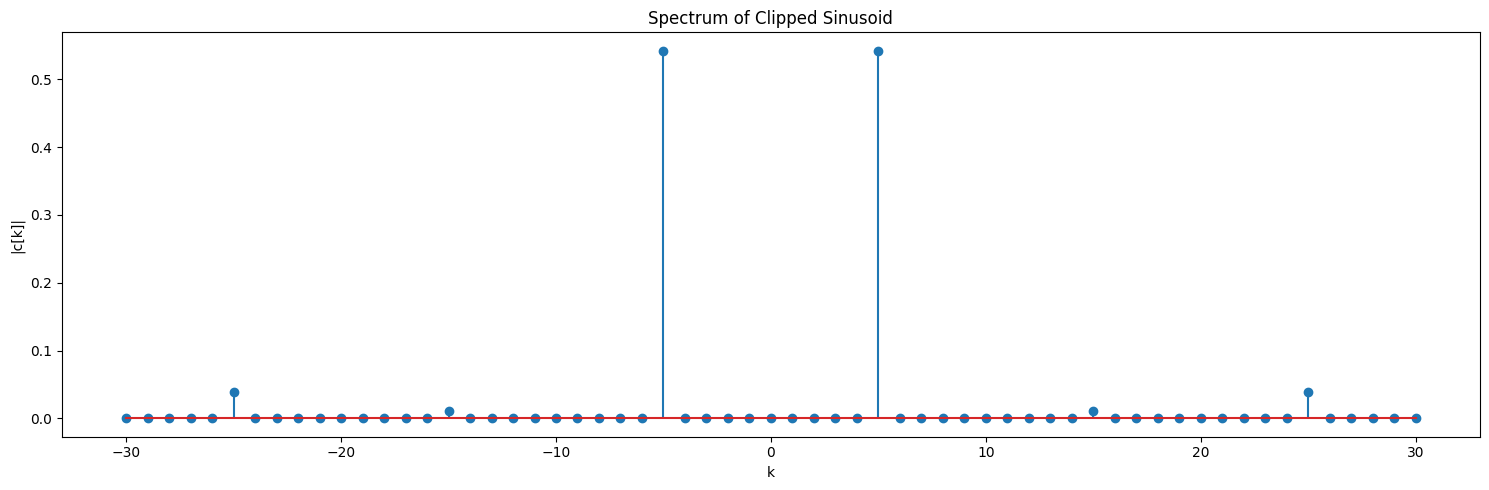

In [36]:

plt.figure(figsize=(15, 5))
K = 30
c = compute_Fourier_Series(x, t, K, T)
ks = np.arange(-K, K+1)

plt.stem(ks, np.abs(c))
plt.title("Spectrum of Clipped Sinusoid")
plt.xlabel("k")
plt.ylabel("|c[k]|")

plt.tight_layout()
plt.show()

The unclipped sinusoid would only show a single strong harmonic at the fundamental frequency (f₀ = 5 Hz).

After clipping, the spectrum shows many higher harmonics with significant amplitude.

This confirms that nonlinear distortion (clipping) introduces strong higher-frequency components.
